# Import Library

In [1]:
import emoji
import pandas as pd
import re
import ast
import numpy as np

In [2]:
df = pd.read_csv('Base Data\data_with_true_label.csv', delimiter=';')
df

,post_shortcode,post_date,commenter_username,comment_text,comment_likes,true_aspect_1,true_aspect_2,true_sentiment,type
0,DFKccJJPeW_,23/01/2025 09:32,tiara_180319,Pemasangan baru tidak ada kelanjutan setelah s...,0,Pemasangan,Pelayanan,Negatif,Pernyataan
1,DFKccJJPeW_,23/01/2025 09:32,dshellysss,Sama naik semua ini juga komplen..biasanya cum...,0,Harga,Harga,Negatif,Pernyataan
2,DFKccJJPeW_,23/01/2025 09:32,shicya_cute,Min kalau puteran PDAM dol itu sya ngadu kesia...,0,Meteran (Macet/Bermasalah),Meteran (Macet/Bermasalah),Netral,Pertanyaan
3,DFKccJJPeW_,23/01/2025 09:32,iirmawulan,Denda PDAM telat ngalah2in pinjol 50k jadi 150...,1,Harga,Harga,Negatif,Pernyataan
4,DFKccJJPeW_,23/01/2025 09:32,aini_al_aydrus,Air ya klo pagi dan jam 3 sore kenapa selalu mati,1,Air Tidak Mengalir,Air Tidak Mengalir,Negatif,Pertanyaan
...,...,...,...,...,...,...,...,...,...
743,DGe2WlxPbvn,25/02/2025 04:15,mell0dz,gunung anyar tambak apa juga terdampak yaa kok...,1,Air Tidak Mengalir,Air Tidak Mengalir,Netral,Pertanyaan
744,DGe2WlxPbvn,25/02/2025 04:15,dodo_hd12,"Hasilnya gimana, min @pdamsuryasembada ??",1,Lainnya,Lainnya,Netral,Pertanyaan
745,DGcY2FIPTcc,24/02/2025 05:20,adiguna2022,min. daerah sidodadi ada pipa besar bocor. moh...,1,Kebocoran,Kebocoran,Negatif,Pernyataan
746,DGZ7MuDvXk3,23/02/2025 06:22,nikelu22,Min. Ini pdam saya mati sekitar tgl segini. Sa...,0,Air Tidak Mengalir,Pelayanan,Netral,Pertanyaan


# Removing Duplicate

In [3]:
df.duplicated().sum()

2

In [4]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df.duplicated().sum()

0

# Preparing Emoji Dataset

In [5]:
df_emoji = pd.read_csv('Base Data\emoji.csv', index_col=0)

In [6]:
# Ganti spasi dengan underscore pada kolom 'name'
df_emoji['name'] = df_emoji['name'].str.replace(' ', '_')
df_emoji['name'] = df_emoji['name'].str.replace('-', '_')
df_emoji['name'] = df_emoji['name'].str.replace('⊛_', '')
df_emoji['name'] = df_emoji['name'].str.replace('"', '')
df_emoji['name'] = df_emoji['name'].str.replace(':', '')
df_emoji['name'] = df_emoji['name'].str.replace(',', '')
df_emoji['name'] = df_emoji['name'].str.replace("'", "")
# Tampilkan 5 baris pertama untuk memastikan hasilnya
print(df_emoji.head())

                              name
0                    grinning_face
1      grinning_face_with_big_eyes
2  grinning_face_with_smiling_eyes
3   beaming_face_with_smiling_eyes
4          grinning_squinting_face


In [7]:
df_emoji.to_csv('emoji_underscore.csv', index=True)

In [8]:
df_emoji

,name
0,grinning_face
1,grinning_face_with_big_eyes
2,grinning_face_with_smiling_eyes
3,beaming_face_with_smiling_eyes
4,grinning_squinting_face
...,...
1811,flag_Zambia
1812,flag_Zimbabwe
1813,flag_England
1814,flag_Scotland


# Cleansing

In [9]:
# --- 1. Baca daftar emoji dari file emoji_underscore.csv ---
emoji_df = pd.read_csv('emoji_underscore.csv')
emoji_df['name'] = emoji_df['name'].astype(str).str.strip()

# Buat pola regex berdasarkan nama emoji (format :emoji_name:)
emoji_names = [re.escape(name) for name in emoji_df['name'] if name]
emoji_pattern = re.compile(r':(' + '|'.join(emoji_names) + r'):', flags=re.IGNORECASE)


# --- 2. Fungsi pembersihan teks ---
def clean_text(text):
    if pd.isna(text):
        return ''
    
    text = str(text).lower()

    # Hapus emoji berdasarkan daftar emoji
    text = emoji_pattern.sub('', text)

    # Hapus URL
    text = re.sub(r'http\S+|www.\S+', '', text)
    
    # Hapus tanda hubung "-"
    text = re.sub('-', ' ', text)
    
    # Hapus mention dan hashtag
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Hapus angka dan simbol non-huruf
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# Terapkan fungsi clean_text ke kolom comment_text
df['cleaned_text'] = df['comment_text'].apply(clean_text)

# --- 4. Hapus baris yang kosong atau hanya berisi emoji (setelah dibersihkan jadi kosong) ---
before = len(df)
df = df[df['cleaned_text'].str.strip().astype(bool)]
after = len(df)

print(f"🧹 {before - after} baris dihapus karena hanya berisi emoji atau kosong.")

🧹 55 baris dihapus karena hanya berisi emoji atau kosong.


In [10]:
print(df['cleaned_text'].to_markdown())

|     | cleaned_text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
|----:|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Tokenize + Stopword Removal + Formalization

In [11]:
import nltk
import string
from nltk.tokenize import word_tokenize

# Pastikan tokenizer sudah diunduh
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# --- Fungsi Slang Removal + Stopword Filtering + Tokenization ---
def slang_remove_tokenize(text):
    if pd.isna(text) or not isinstance(text, str):
        return []

    # Baca daftar stopwords
    with open("combined_stop_words.txt", "r", encoding="utf-8") as f:
        stop_words = f.read().splitlines()

    # Baca daftar slang words
    with open("update_combined_slang_words.txt", "r", encoding="utf-8") as f:
        slang_words = ast.literal_eval(f.read())

    # Tokenisasi teks
    word_tokens = word_tokenize(text.lower())

    # Ganti slang dengan padanan katanya
    normalized_tokens = [slang_words.get(w, w) for w in word_tokens]

    # Filter stopword dan tanda baca
    filtered_tokens = [
        w for w in normalized_tokens 
        if w not in stop_words and w not in string.punctuation and w.strip()
    ]

    return filtered_tokens  # bisa juga ' '.join(filtered_tokens) jika ingin string

df['tokens'] = df['cleaned_text'].apply(slang_remove_tokenize)

print(df[['cleaned_text', 'tokens']].to_markdown())

|     | cleaned_text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            | tokens                                                                                                                                                                                                                

# Drop Empty row

In [12]:
# --- 2️⃣ Jika kolom tokens disimpan dalam bentuk string list (contoh: "['air', 'keruh']") ---
# Ubah string list menjadi list Python sesungguhnya
def safe_eval(x):
    try:
        if isinstance(x, str) and x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        elif isinstance(x, float) and pd.isna(x):
            return []
        else:
            return x
    except:
        return []

df['tokens'] = df['tokens'].apply(safe_eval)

# --- 3️⃣ Hapus baris dengan kolom tokens kosong ---
before = len(df)
df = df[df['tokens'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
after = len(df)

print(f"✅ Baris kosong pada kolom 'tokens' berhasil dihapus.")
print(f"🗑️ Total baris dihapus: {before - after}")
# df.to_csv("cleaned_tokens_dataset.csv", sep = ';', index=False, encoding='utf-8-sig')


✅ Baris kosong pada kolom 'tokens' berhasil dihapus.
🗑️ Total baris dihapus: 10


# Stemming

In [13]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()
df['final_data'] = df['tokens'].apply(lambda x: stemmer.stem(" ".join(x)) if isinstance(x, list) else stemmer.stem(x))
print(df['final_data'].to_markdown())
df[['post_shortcode', 'comment_text', 'cleaned_text', 'tokens', 'final_data']].to_csv("final_stemmed_dataset.csv", sep =';', index=False, encoding='utf-8-sig')

|     | final_data                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
|----:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Feature Extraction (TF-IDF)

In [38]:
# ============================================================
# EKSTRAKSI FITUR MENGGUNAKAN TF-IDF (SETELAH STEMMING)
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

# --- 1. Pastikan data sudah ada dari tahap sebelumnya ---
# Kolom 'final_data' berisi hasil stemming berbentuk string
# Contoh: "air kotor banget", "layan kurang cepat"

# --- 2. Inisialisasi TF-IDF Vectorizer ---
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x.split(),  # dataset sudah bertoken
    preprocessor=lambda x: x,       # tidak ubah teks lagi
    token_pattern=None,             # nonaktifkan regex default
    max_features=1000,              # ambil 1000 fitur terpenting
    ngram_range=(1,1),              # unigram
    min_df=2                        # kata muncul minimal di 2 dokumen
)

# --- 3. Transformasi teks menjadi representasi numerik ---
tfidf_matrix = tfidf_vectorizer.fit_transform(df['final_data'])

# --- 4. Konversi ke DataFrame agar mudah dibaca ---
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

# --- 5. Gabungkan hasil TF-IDF dengan data asli ---
df_tfidf = pd.concat([df[['post_shortcode', 'final_data']], tfidf_df], axis=1)

# --- 6. Simpan hasil ekstraksi fitur ---
# df_tfidf.to_csv('comments_tfidf_features.csv', index=False, encoding='utf-8-sig')

# --- 7. Informasi hasil ---
print("✅ Ekstraksi fitur TF-IDF selesai.")
print(f"Jumlah fitur yang dihasilkan: {tfidf_df.shape[1]}")
print("Contoh hasil TF-IDF:")
print(tfidf_df.head())
df_tfidf.to_csv("tfidf.csv", sep = ';', index=False, encoding='utf-8-sig')

✅ Ekstraksi fitur TF-IDF selesai.
Jumlah fitur yang dihasilkan: 556
Contoh hasil TF-IDF:
     a  aamiin  abu  ada     admin       adu      aduh  agak  aidzin  \
0  0.0     0.0  0.0  0.0  0.000000  0.000000  0.000000   0.0     0.0   
1  0.0     0.0  0.0  0.0  0.000000  0.000000  0.407868   0.0     0.0   
2  0.0     0.0  0.0  0.0  0.227042  0.427326  0.000000   0.0     0.0   
3  0.0     0.0  0.0  0.0  0.000000  0.000000  0.000000   0.0     0.0   
4  0.0     0.0  0.0  0.0  0.000000  0.000000  0.000000   0.0     0.0   

        air  ...  wetan  whatsapp  wikanti  wilayah  wiyung  woi  wonocolo  \
0  0.000000  ...    0.0   0.49189      0.0      0.0     0.0  0.0       0.0   
1  0.000000  ...    0.0   0.00000      0.0      0.0     0.0  0.0       0.0   
2  0.000000  ...    0.0   0.00000      0.0      0.0     0.0  0.0       0.0   
3  0.000000  ...    0.0   0.00000      0.0      0.0     0.0  0.0       0.0   
4  0.240556  ...    0.0   0.00000      0.0      0.0     0.0  0.0       0.0   

   wonokr

# Thresholding TF-IDF per baris berdasarkan nilai maksimum

In [39]:
df_tfidf = pd.read_csv("tfidf.csv", delimiter=';')
# Ambil hanya kolom fitur TF-IDF (bukan kolom post_shortcode & final_data)
tfidf_only = df_tfidf.drop(columns=['post_shortcode', 'final_data'])

# Konversi ke array untuk proses cepat
tfidf_values = tfidf_only.values

# Proses threshold per baris
for i in range(tfidf_values.shape[0]):
    row = tfidf_values[i]
    max_val = row.max()

    if max_val > 0:
        threshold = max_val / 2
        # nilai < threshold → jadi 0, nilai >= threshold → tetap
        row[row < threshold] = 0
        tfidf_values[i] = row

# Kembalikan ke DataFrame
tfidf_thresholded_df = pd.DataFrame(tfidf_values, columns=tfidf_only.columns)

# Gabungkan lagi dengan kolom awal
df_tfidf_thresholded = pd.concat(
    [df[['post_shortcode', 'final_data']], tfidf_thresholded_df],
    axis=1
)

# Simpan ke file baru
df_tfidf_thresholded.to_csv("tfidf_thresholded.csv", sep=';', index=False, encoding='utf-8-sig')

print("✅ Thresholding TF-IDF selesai!")
print("📁 Hasil disimpan sebagai tfidf_thresholded.csv")

✅ Thresholding TF-IDF selesai!
📁 Hasil disimpan sebagai tfidf_thresholded.csv


In [ ]:
# ============================================================
# 9️⃣ Mengambil semua kata TF-IDF > 0
#    + nilai TF-IDF maksimum
#    + frekuensi kemunculan (document frequency)
# ============================================================

# Ambil hanya kolom fitur TF-IDF (tanpa metadata)
tfidf_cols = df_tfidf_thresholded.drop(columns=['post_shortcode', 'final_data'])

# List untuk menyimpan hasil
word_stats = []

# Iterasi tiap kata (kolom)
for col in tfidf_cols.columns:
    # Nilai TF-IDF maksimum
    max_tfidf = tfidf_cols[col].max()
    
    if max_tfidf > 0:
        # Frekuensi kemunculan (jumlah dokumen dengan TF-IDF > 0)
        freq = (tfidf_cols[col] > 0).sum()
        
        word_stats.append((col, max_tfidf, freq))

# Urutkan berdasarkan TF-IDF maksimum (descending)
word_stats = sorted(word_stats, key=lambda x: x[1], reverse=True)

# ============================================================
# Tampilkan hasil
# ============================================================

print("==============================================================")
print(f"Total unique words (TF-IDF > 0): {len(word_stats)}")
print("==============================================================")
print(f"{'Kata':<25} {'Max_TFIDF':>12} {'Frekuensi':>12}")
print("--------------------------------------------------------------")

for word, max_val, freq in word_stats:
    print(f"{word:<25} {max_val:>12.6f} {freq:>12}")

Total unique words (TF-IDF > 0): 541
Kata                         Max_TFIDF    Frekuensi
--------------------------------------------------------------
aamiin                        1.000000            2
admin                         1.000000           33
air                           1.000000           37
aja                           1.000000            6
alhamdulillah                 1.000000            5
beli                          1.000000            2
bohong                        1.000000            2
cerah                         1.000000            3
edukasi                       1.000000            2
enak                          1.000000            2
harga                         1.000000            5
hujan                         1.000000            3
indah                         1.000000            5
jam                           1.000000           28
kelas                         1.000000            2
keren                         1.000000           15
kosong          

# Aspect Based Classification Using Cosine Similarity

In [41]:
# =========================================================
# 🧩 Aspect-Based Classification menggunakan Cosine Similarity
#   (Hanya untuk data yang true_aspect_1 ≠ "Lainnya")
# =========================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# =========================================================
# 1️⃣ FILTER DATA: Abaikan baris dengan true_aspect_1 = "Lainnya"
# =========================================================

df_filtered = df[df['true_aspect_1'] != "Lainnya"].reset_index(drop=True)

print(f"Jumlah data sebelum filter : {len(df)}")
print(f"Jumlah data sesudah filter : {len(df_filtered)}")

# =========================================================
# 2️⃣ Definisikan Aspek dan Kata Kunci Representatif
# =========================================================

aspects = {
    "Air Kotor/Bau" : ["kaporit", "kualitas", "buruk", "keruh", "warna", "bau", "kotor", "putih"],
    "Air Tidak Mengalir" : ["dampak", "debit", "macet", "tekan", "alir", "keluar", "kecil", "mati"],
    "Kebocoran" : ["bocor", "pipa", "pecah", "resap"],
    "Pemasangan" : ["pasang", "sambung", "instalasi", "survey", "aju"],
    "Meteran (Macet/Bermasalah)" : ["pindah", "meter", "patah", "putar", "embun", "buram", "macet", "masalah", "ganti", "rusak"],
    "Pelayanan" : ["whatsapp", "adu", "datang", "tindak", "dadak", "pemberitahuan", "tanggap", "respon", "update", "pesan", "cepat", "kali", "layan"],
    "Harga" : ["bayar", "biaya", "mahal", "murah", "tagih", "rekening", "tarif", "denda", "gratis"]
}

# Gabungkan kata kunci per aspek menjadi satu kalimat
aspect_sentences = [" ".join(words) for words in aspects.values()]
aspect_names = list(aspects.keys())

# =========================================================
# 3️⃣ TF-IDF hanya untuk data hasil filter
# =========================================================

vectorizer = TfidfVectorizer()

combined_corpus = df_filtered['final_data'].tolist() + aspect_sentences
tfidf_matrix = vectorizer.fit_transform(combined_corpus)

# Pisahkan kembali antara komentar dan aspek
comment_vectors = tfidf_matrix[:-len(aspect_names)]
aspect_vectors = tfidf_matrix[-len(aspect_names):]

# =========================================================
# 4️⃣ Hitung Cosine Similarity antar komentar dan aspek
# =========================================================

cosine_sim = cosine_similarity(comment_vectors, aspect_vectors)

# =========================================================
# 5️⃣ Klasifikasi aspek berdasarkan nilai maksimum
# =========================================================

df_filtered['predicted_aspect'] = [
    aspect_names[i] for i in cosine_sim.argmax(axis=1)
]

df_filtered['similarity_score'] = cosine_sim.max(axis=1)

# =========================================================
# 6️⃣ Simpan hasil klasifikasi aspek
# =========================================================

df_filtered[['comment_text', 'final_data', 'predicted_aspect', 'similarity_score']].to_csv(
    "aspect_classification_only_non_lainnya.csv",
    sep=';',
    index=False,
    encoding='utf-8-sig'
)

print("==============================================")
print("✅ Klasifikasi aspek selesai (tanpa 'Lainnya')!")
print("📁 File disimpan sebagai: aspect_classification_only_non_lainnya.csv")
print("==============================================")
print(df_filtered[['comment_text', 'predicted_aspect', 'similarity_score']].head().to_markdown())

Jumlah data sebelum filter : 681
Jumlah data sesudah filter : 445
✅ Klasifikasi aspek selesai (tanpa 'Lainnya')!
📁 File disimpan sebagai: aspect_classification_only_non_lainnya.csv
|    | comment_text                                                                                                                                        | predicted_aspect           |   similarity_score |
|---:|:----------------------------------------------------------------------------------------------------------------------------------------------------|:---------------------------|-------------------:|
|  0 | Pemasangan baru tidak ada kelanjutan setelah survey.katanya bisa komplain cs lewat wa.sedangkan di wa gak ada tanggapan….                           | Pelayanan                  |          0.259147  |
|  1 | Sama naik semua ini juga komplen..biasanya cuma 90an sekrang 230an..duh semua serba membayar to …jadi g percaya sama pemerintah begini:crying_face: | Harga                      |          0.0

In [42]:
import pandas as pd

# Pastikan df sudah berisi semua variabel:
# final_data, predicted_aspect, true_aspect_1, similarity_score

# ================================
# 1️⃣ Filter Data Sesuai Aturan
# ================================

filtered_aspct = df_filtered[
    (df_filtered['predicted_aspect'] == "Air Kotor/Bau") &
    (df_filtered['true_aspect_1'] == "Air Tidak Mengalir")
]

# ================================
# 2️⃣ Pilih Kolom Sesuai Urutan
# ================================
filtered_aspct = filtered_aspct[
    ['comment_text','final_data', 'predicted_aspect', 'true_aspect_1', 'similarity_score']
]

# ================================
# 3️⃣ Simpan ke File CSV
# ================================
filtered_aspct.to_csv(
    "..\Miss Classified Data\ABSA TFIDF Pak Ali.csv",
    sep=';',
    index=False,
    encoding='utf-8-sig'
)

print("✅ File berhasil dibuat:")
print("..\Miss Classified Data\ABSA TFIDF Pak Ali.csv")
print(f"Total data: {len(filtered_aspct)}")
print(filtered_aspct.head().to_markdown(index=False))


✅ File berhasil dibuat:
..\Miss Classified Data\ABSA TFIDF Pak Ali.csv
Total data: 43
| comment_text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              | final_data                                                                                                                                          

# Visualisasi Penggolongan Aspek

📊 Statistik Aspek (Jumlah & Rata-rata Similarity):
| predicted_aspect           |   Jumlah_Kemunculan |   Rata_rata_Similarity |
|:---------------------------|--------------------:|-----------------------:|
| Air Tidak Mengalir         |                 149 |              0.101948  |
| Air Kotor/Bau              |                 100 |              0.0528841 |
| Pelayanan                  |                  69 |              0.15058   |
| Harga                      |                  47 |              0.138159  |
| Meteran (Macet/Bermasalah) |                  44 |              0.136691  |
| Pemasangan                 |                  20 |              0.182178  |
| Kebocoran                  |                  16 |              0.194533  |


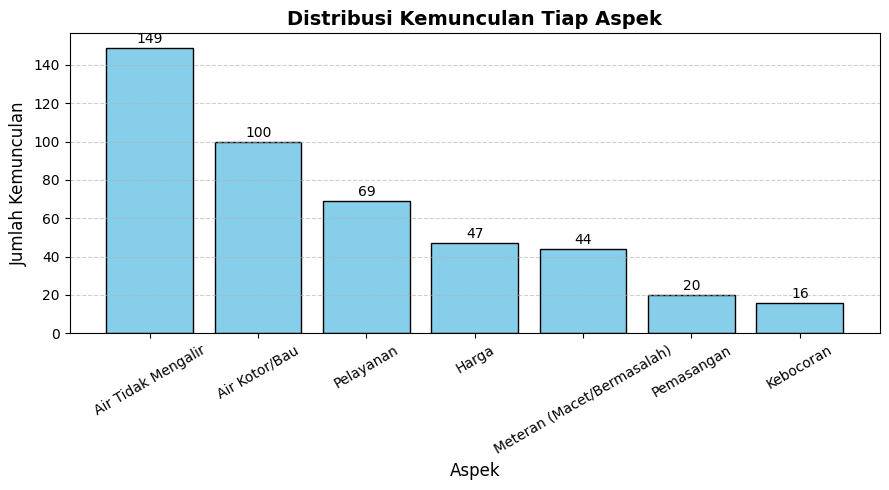

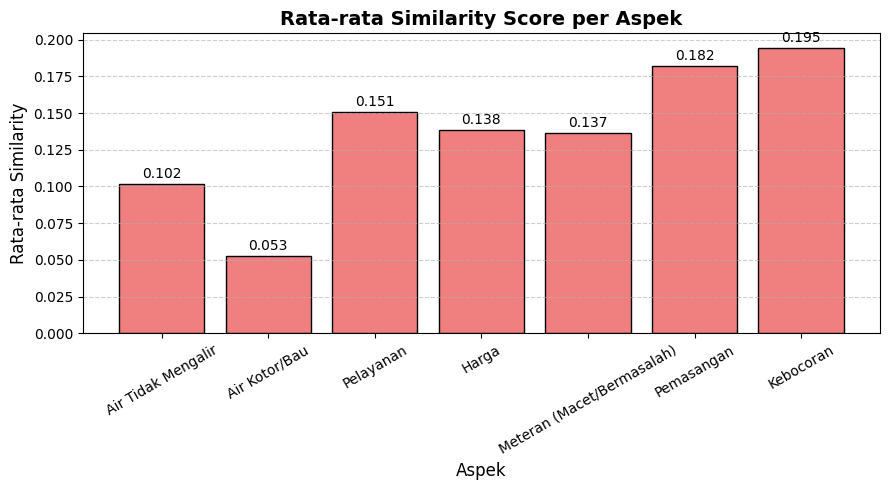


🎯 EVALUASI AKURASI

✅ Akurasi Aspect Classification: 0.6787

📄 Classification Report:
                            precision    recall  f1-score   support

             Air Kotor/Bau       0.36      0.88      0.51        41
        Air Tidak Mengalir       0.97      0.63      0.77       227
                     Harga       0.79      0.79      0.79        47
                 Kebocoran       0.31      0.71      0.43         7
Meteran (Macet/Bermasalah)       0.75      0.72      0.73        46
                 Pelayanan       0.49      0.61      0.54        56
                Pemasangan       0.65      0.62      0.63        21

                  accuracy                           0.68       445
                 macro avg       0.62      0.71      0.63       445
              weighted avg       0.78      0.68      0.70       445



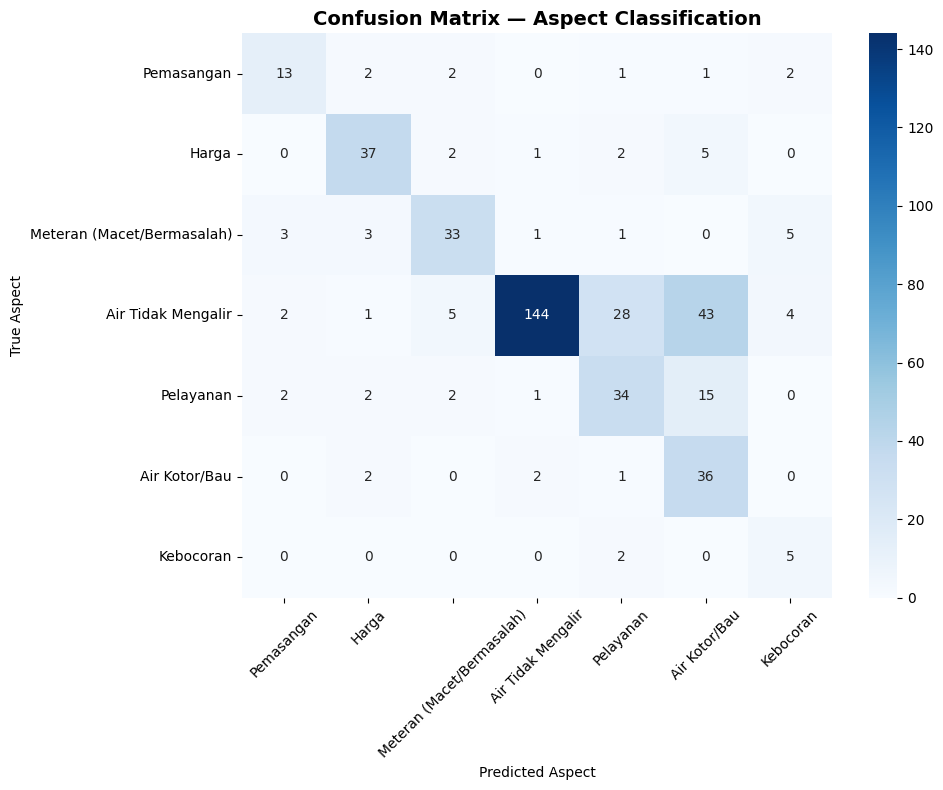


📌 Jumlah Tiap Aspek (True Label)
| Aspek                      |   Jumlah |
|:---------------------------|---------:|
| Air Tidak Mengalir         |      227 |
| Pelayanan                  |       56 |
| Harga                      |       47 |
| Meteran (Macet/Bermasalah) |       46 |
| Air Kotor/Bau              |       41 |
| Pemasangan                 |       21 |
| Kebocoran                  |        7 |


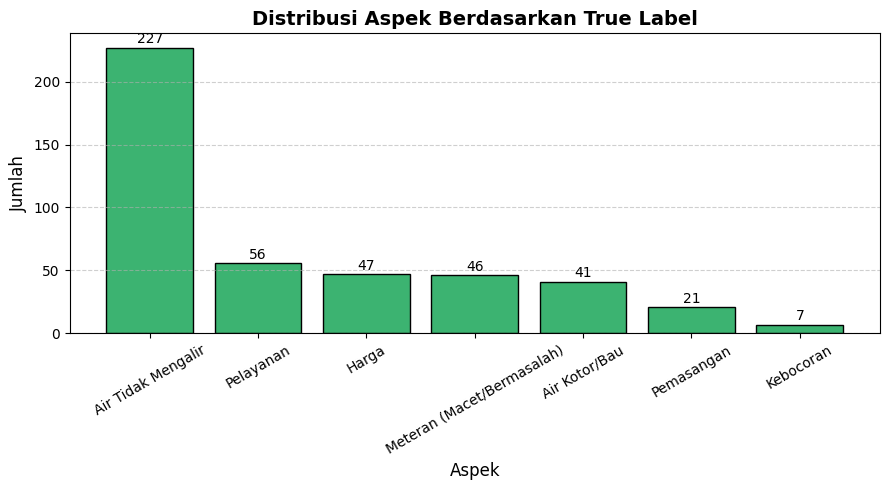

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# =========================================================
# 1️⃣ BACA DATA
# =========================================================

# Pastikan kolom ada
if 'predicted_aspect' not in df_filtered.columns or 'true_aspect_1' not in df_filtered.columns:
    raise KeyError("Kolom 'predicted_aspect' atau 'true_aspect_1' tidak ditemukan dalam dataset!")

# =========================================================
# 2️⃣ HITUNG STATISTIK ASPEK
# =========================================================
aspect_stats = (
    df_filtered.groupby('predicted_aspect')
      .agg(Jumlah_Kemunculan=('predicted_aspect', 'count'),
           Rata_rata_Similarity=('similarity_score', 'mean'))
      .reset_index()
      .sort_values('Jumlah_Kemunculan', ascending=False)
)

print("📊 Statistik Aspek (Jumlah & Rata-rata Similarity):")
print(aspect_stats.to_markdown(index=False))

# =========================================================
# 3️⃣ BAR CHART: JUMLAH KEMUNCULAN
# =========================================================
plt.figure(figsize=(9, 5))
bars = plt.bar(aspect_stats['predicted_aspect'], aspect_stats['Jumlah_Kemunculan'],
               color='skyblue', edgecolor='black')

plt.title("Distribusi Kemunculan Tiap Aspek", fontsize=14, fontweight='bold')
plt.xlabel("Aspek", fontsize=12)
plt.ylabel("Jumlah Kemunculan", fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval),
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# =========================================================
# 4️⃣ BAR CHART: RATA-RATA SIMILARITY
# =========================================================
plt.figure(figsize=(9, 5))
bars2 = plt.bar(aspect_stats['predicted_aspect'], aspect_stats['Rata_rata_Similarity'],
                color='lightcoral', edgecolor='black')

plt.title("Rata-rata Similarity Score per Aspek", fontsize=14, fontweight='bold')
plt.xlabel("Aspek", fontsize=12)
plt.ylabel("Rata-rata Similarity", fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}",
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# =========================================================
# 5️⃣ EVALUASI AKURASI ASPECT-BASED CLASSIFICATION
# =========================================================

print("\n======================")
print("🎯 EVALUASI AKURASI")
print("======================")

y_true = df_filtered['true_aspect_1']
y_pred = df_filtered['predicted_aspect']

# Akurasi
accuracy = accuracy_score(y_true, y_pred)
print(f"\n✅ Akurasi Aspect Classification: {accuracy:.4f}")

# Classification Report
print("\n📄 Classification Report:")
print(classification_report(y_true, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=y_true.unique())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=y_true.unique(),
            yticklabels=y_true.unique())
plt.title("Confusion Matrix — Aspect Classification", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Aspect")
plt.ylabel("True Aspect")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================================================
# 6️⃣ HITUNG JUMLAH MASING-MASING ASPEK (TRUE LABEL)
# =========================================================

print("\n==============================")
print("📌 Jumlah Tiap Aspek (True Label)")
print("==============================")

true_counts = df_filtered['true_aspect_1'].value_counts().reset_index()
true_counts.columns = ['Aspek', 'Jumlah']
print(true_counts.to_markdown(index=False))

# --- Bar chart jumlah aspek dari true_aspect_1 ---
plt.figure(figsize=(9, 5))
bars3 = plt.bar(true_counts['Aspek'], true_counts['Jumlah'],
                color='mediumseagreen', edgecolor='black')

plt.title("Distribusi Aspek Berdasarkan True Label", fontsize=14, fontweight='bold')
plt.xlabel("Aspek", fontsize=12)
plt.ylabel("Jumlah", fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Tambahkan label jumlah di atas batang
for bar in bars3:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval),
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Sentiment Analysis Using Rule Based

In [44]:
# =========================================================
# 🧠 Rule-Based Sentiment Analysis TANPA Lexicon
# =========================================================

# --- 2️⃣ Daftar pola kata berdasarkan aturan linguistik ---
positive_words = [
    "bagus", "baik", "cepat", "ramah", "bersih", "jernih", "tanggap", 
    "memuaskan", "puas", "mantap", "ok", "top"
]

negative_words = [
    "buruk", "lama", "lambat", "keruh", "bau", "mahal", "kecewa", "macet",
    "jelek", "lemot", "mengecewakan", "bocor", "mati", "lemah", "parah"
]

negations = ["tidak", "nggak", "ga", "gak", "kurang", "belum", "bukan"]
intensifiers = ["sangat", "banget", "sekali", "amat", "terlalu"]

# --- 3️⃣ Fungsi utama analisis sentimen berbasis aturan ---
def rule_based_sentiment(text):
    if pd.isna(text) or not isinstance(text, str):
        return 0

    text = text.lower()
    words = re.findall(r'\b\w+\b', text)
    sentiment_score = 0

    for i, w in enumerate(words):
        # Deteksi kata positif
        if w in positive_words:
            score = 1
            # Cek jika ada negasi sebelumnya → ubah jadi negatif
            if i > 0 and words[i-1] in negations:
                score = -1
            # Cek jika ada penegas sebelumnya → tambah bobot
            elif i > 0 and words[i-1] in intensifiers:
                score = 2
            sentiment_score += score

        # Deteksi kata negatif
        elif w in negative_words:
            score = -1
            # Cek jika ada negasi sebelumnya → ubah jadi positif
            if i > 0 and words[i-1] in negations:
                score = 1
            # Cek jika ada penegas sebelumnya → kurangi lebih dalam
            elif i > 0 and words[i-1] in intensifiers:
                score = -2
            sentiment_score += score

    # --- Aturan tambahan untuk ekspresi umum ---
    if re.search(r"terima kasih|makasih|thank", text):
        sentiment_score += 1
    if re.search(r"tolong|kapan|kok|kenapa", text):
        sentiment_score -= 1

    # --- Tentukan label sentimen ---
    if sentiment_score > 0:
        return 1   # positif
    elif sentiment_score < 0:
        return -1  # negatif
    else:
        return 0   # netral

# --- 4️⃣ Terapkan fungsi ke dataset ---
df_filtered['sentiment_value'] = df_filtered['final_data'].apply(rule_based_sentiment)
df_filtered['sentiment_label'] = df_filtered['sentiment_value'].map({1: "Positif", 0: "Netral", -1: "Negatif"})

# --- 5️⃣ Simpan hasil ke CSV ---
output_path = "sentiment_analysis_rulebased_no_lexicon.csv"
df_filtered[['post_shortcode', 'comment_text', 'final_data', 'predicted_aspect', 'sentiment_label', 'sentiment_value']].to_csv(
    output_path, sep = ';', index=False, encoding='utf-8-sig'
)

print("✅ Analisis sentimen rule-based selesai tanpa lexicon!")
print(f"💾 Hasil disimpan di: {output_path}")
print(df_filtered[['comment_text', 'predicted_aspect', 'sentiment_label', 'sentiment_value']].head().to_markdown())


✅ Analisis sentimen rule-based selesai tanpa lexicon!
💾 Hasil disimpan di: sentiment_analysis_rulebased_no_lexicon.csv
|    | comment_text                                                                                                                                        | predicted_aspect           | sentiment_label   |   sentiment_value |
|---:|:----------------------------------------------------------------------------------------------------------------------------------------------------|:---------------------------|:------------------|------------------:|
|  0 | Pemasangan baru tidak ada kelanjutan setelah survey.katanya bisa komplain cs lewat wa.sedangkan di wa gak ada tanggapan….                           | Pelayanan                  | Negatif           |                -1 |
|  1 | Sama naik semua ini juga komplen..biasanya cuma 90an sekrang 230an..duh semua serba membayar to …jadi g percaya sama pemerintah begini:crying_face: | Harga                      | Netral           

# Sentiment Analysis Visualization

📈 Distribusi Sentimen per Aspek:
|    | predicted_aspect           | sentiment_label   |   jumlah |
|---:|:---------------------------|:------------------|---------:|
|  0 | Air Kotor/Bau              | Negatif           |       23 |
|  1 | Air Kotor/Bau              | Netral            |       65 |
|  2 | Air Kotor/Bau              | Positif           |       12 |
|  3 | Air Tidak Mengalir         | Negatif           |       87 |
|  4 | Air Tidak Mengalir         | Netral            |       57 |
|  5 | Air Tidak Mengalir         | Positif           |        5 |
|  6 | Harga                      | Negatif           |        9 |
|  7 | Harga                      | Netral            |       35 |
|  8 | Harga                      | Positif           |        3 |
|  9 | Kebocoran                  | Negatif           |       10 |
| 10 | Kebocoran                  | Netral            |        6 |
| 11 | Meteran (Macet/Bermasalah) | Negatif           |        8 |
| 12 | Meteran (Macet/Bermasa

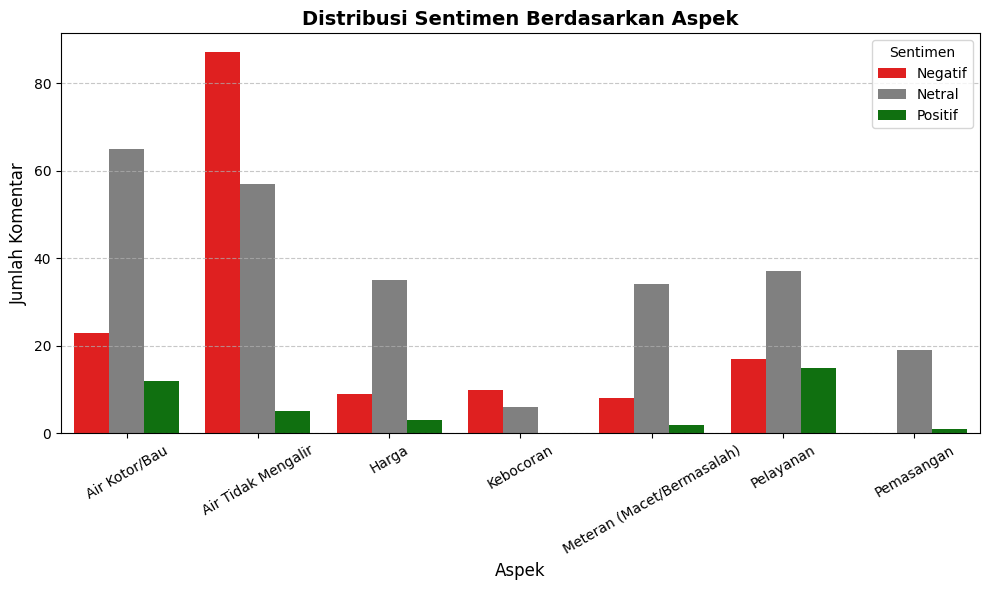

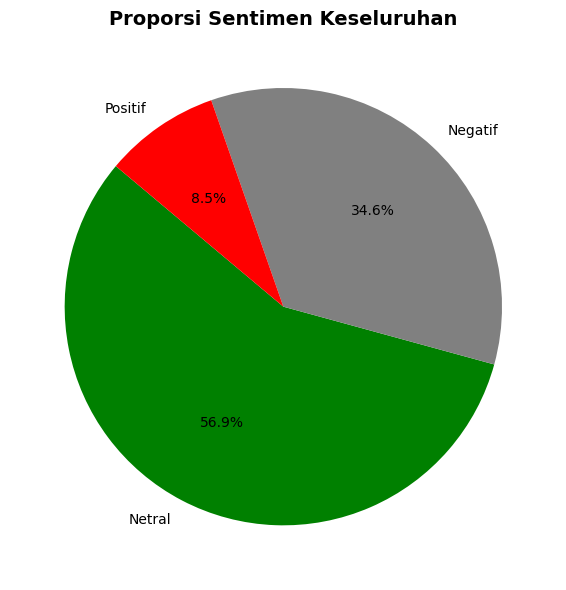

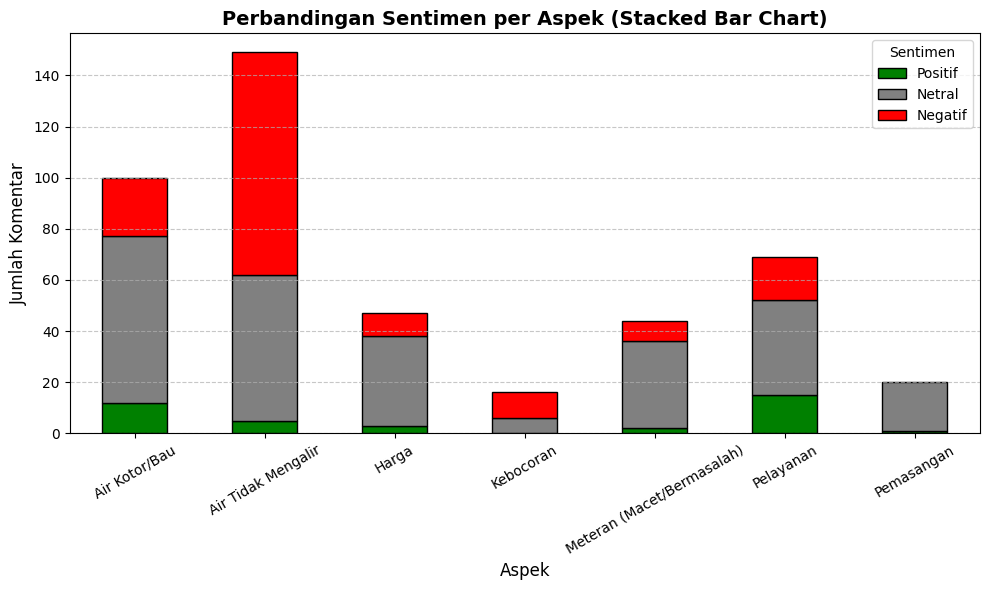

In [45]:
# =========================================================
# 📊 Visualisasi Sentimen Berdasarkan Aspek (Final)
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# --- 2️⃣ Hitung jumlah komentar per aspek & label sentimen ---
sentiment_counts = (
    df_filtered.groupby(['predicted_aspect', 'sentiment_label'])
      .size()
      .reset_index(name='jumlah')
)

# --- 3️⃣ Hitung total keseluruhan untuk pie chart ---
total_sentiment = (
    df_filtered['sentiment_label']
    .value_counts()
    .reset_index()
)
total_sentiment.columns = ['sentiment_label', 'jumlah']

print("📈 Distribusi Sentimen per Aspek:")
print(sentiment_counts.to_markdown())

# =========================================================
#  BAR CHART: DISTRIBUSI SENTIMEN BERDASARKAN ASPEK
# =========================================================
plt.figure(figsize=(10, 6))
sns.barplot(
    data=sentiment_counts,
    x='predicted_aspect',
    y='jumlah',
    hue='sentiment_label',
    palette={'Positif': 'green', 'Negatif': 'red', 'Netral': 'gray'}
)
plt.title("Distribusi Sentimen Berdasarkan Aspek", fontsize=14, fontweight='bold')
plt.xlabel("Aspek", fontsize=12)
plt.ylabel("Jumlah Komentar", fontsize=12)
plt.xticks(rotation=30)
plt.legend(title="Sentimen")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# =========================================================
#  PIE CHART: PROPORSI SENTIMEN KESELURUHAN
# =========================================================
plt.figure(figsize=(6, 6))
plt.pie(
    total_sentiment['jumlah'],
    labels=total_sentiment['sentiment_label'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['green', 'gray', 'red']
)
plt.title("Proporsi Sentimen Keseluruhan", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =========================================================
#  STACKED BAR CHART: KOMBINASI ASPEK DAN SENTIMEN
# =========================================================
# Pivot data agar mudah diplot
pivot_df_filtered = sentiment_counts.pivot(index='predicted_aspect', columns='sentiment_label', values='jumlah').fillna(0)
pivot_df_filtered = pivot_df_filtered[['Positif', 'Netral', 'Negatif']] if set(['Positif','Negatif','Netral']).issubset(pivot_df_filtered.columns) else pivot_df_filtered

pivot_df_filtered.plot(kind='bar', stacked=True, color=['green', 'gray', 'red'], figsize=(10,6), edgecolor='black')
plt.title("Perbandingan Sentimen per Aspek (Stacked Bar Chart)", fontsize=14, fontweight='bold')
plt.xlabel("Aspek", fontsize=12)
plt.ylabel("Jumlah Komentar", fontsize=12)
plt.xticks(rotation=30)
plt.legend(title="Sentimen")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()